# The Gaussian Log-Return Model


---

##  Introduction

When modeling the price of a financial asset $(S_t)_{t \geq 0}$, a natural question arises: **what information is most relevant?**

Rather than working directly with the price $S_t$ or its absolute variation $V_t = S_{t+1} - S_t$, practitioners prefer to work with the **log-return**, defined as:

$$L_t = \log\left(\frac{S_{t+1}}{S_t}\right)$$

**Why log-returns?**

- Unlike absolute variations, log-returns are scale-invariant (independent of the price level)
- They are additively composable over time:

$$L_{t;\,p} = L_t + L_{t+1} + \cdots + L_{t+p-1}$$

- They closely approximate the simple return $R_t = \frac{S_{t+1} - S_t}{S_t}$ for small variations (by a first-order Taylor expansion: $\log(1+x) \approx x$)

---



### Assumptions

The model rests on two assumptions:

**H1 — Independence**

The log-returns $(L_t)_{t \geq 0}$ are **mutually independent**:

$$L_t \perp L_s \quad \forall\, t \neq s$$

No autocorrelation: the return on day $t$ carries no information about future returns.

**H2 — Identical Gaussian distribution**

Each log-return follows the same normal distribution:

$$L_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(\nu,\, \sigma^2)$$

where:
- $\nu \in \mathbb{R}$ — mean log-return  
- $\sigma^2 > 0$ — variance  
- $\sigma > 0$ — **volatility** (the key risk parameter)

---

---

## Key Result — Distribution of $\log(S_\tau / S_0)$ 

### Statement

Under the Gaussian log-return model, for any $\tau \geq 1$:

$$\boxed{\log\left(\frac{S_\tau}{S_0}\right) \sim \mathcal{N}(\tau\nu,\; \tau\sigma^2)}$$

### Proof

By telescoping decomposition:

$$\log\left(\frac{S_\tau}{S_0}\right) = \sum_{k=0}^{\tau-1} \underbrace{\log\left(\frac{S_{k+1}}{S_k}\right)}_{= L_k \sim \mathcal{N}(\nu,\,\sigma^2)}$$

Since the $L_k$ are **i.i.d.** $\mathcal{N}(\nu, \sigma^2)$, by stability of the normal distribution:

$$\sum_{k=0}^{\tau-1} L_k \sim \mathcal{N}(\tau\nu,\; \tau\sigma^2) \qquad \blacksquare$$

**Consequence:** $S_\tau$ follows a **log-normal distribution**:

$$S_\tau = S_0 \cdot e^X, \quad X \sim \mathcal{N}(\tau\nu,\, \tau\sigma^2)$$




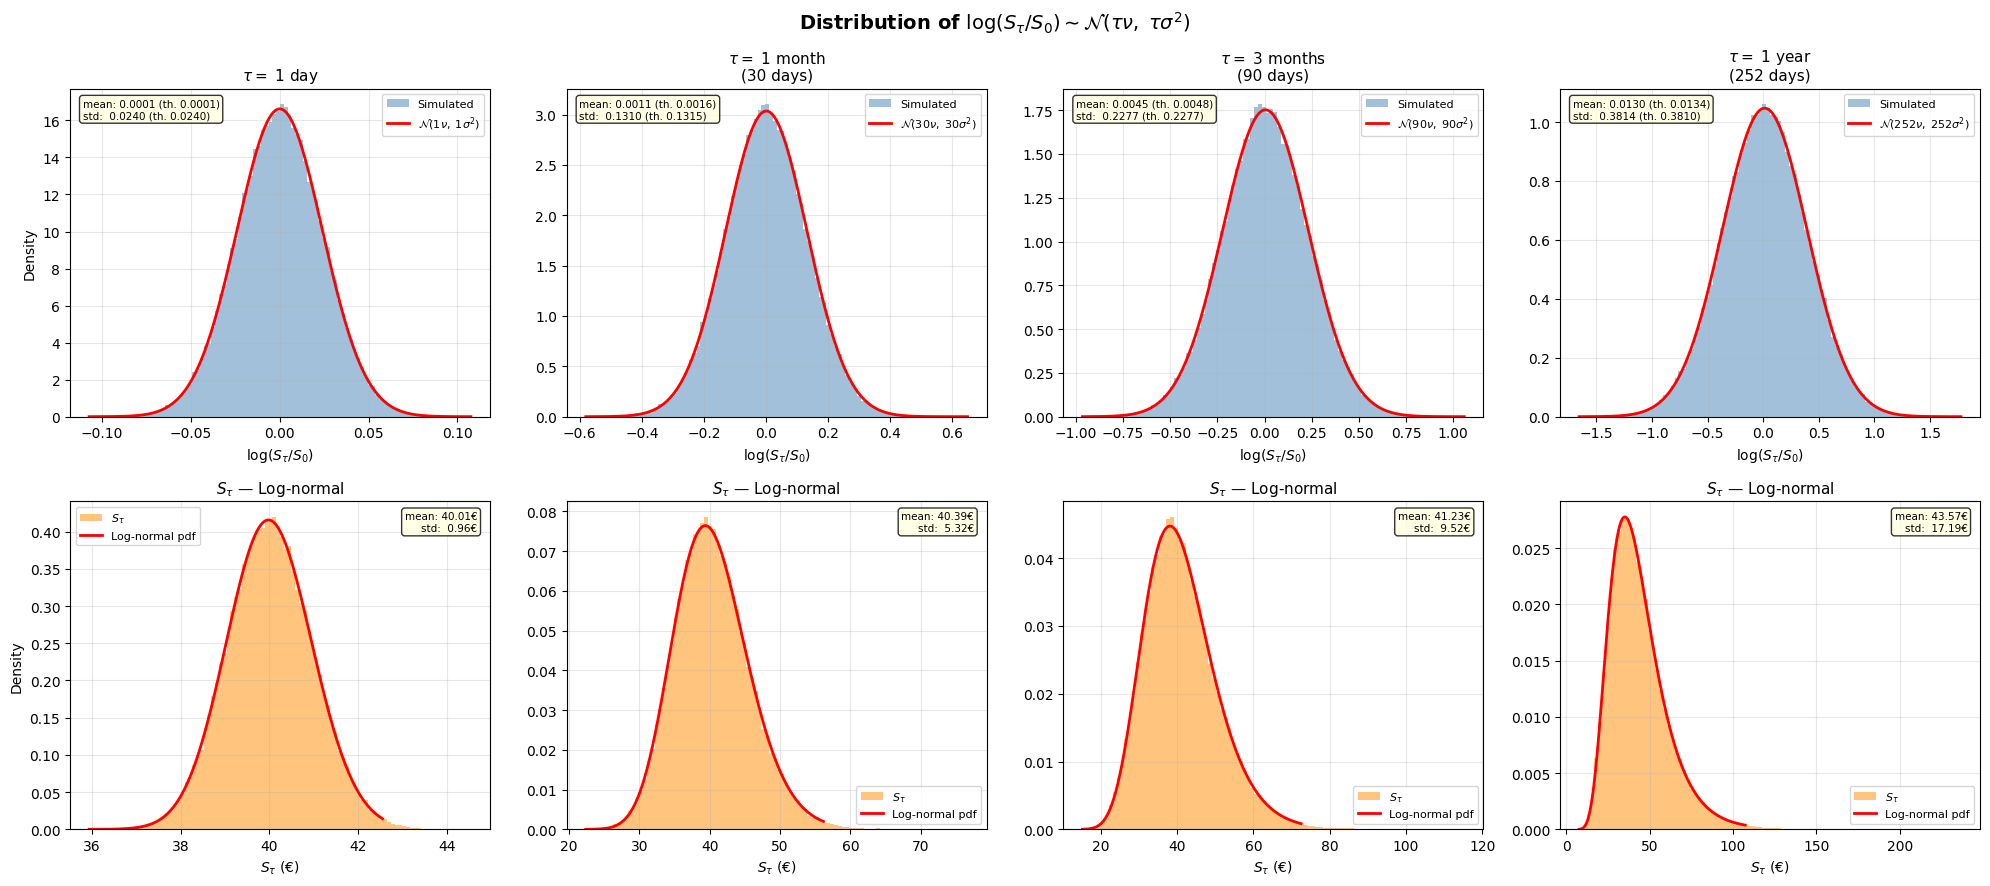

 Numerical Verification
  Model: nu = 5.30e-05,  sigma = 0.024,  S0 = 40.0
Horizon          E[log]   Th. E[log]   Std[log]    Th. Std
------------------------------------------------------------
1d              0.00006      0.00005    0.02402    0.02400
30d             0.00175      0.00159    0.13176    0.13145
90d             0.00429      0.00477    0.22776    0.22768
252d            0.00875      0.01336    0.38022    0.38099


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

# Parameters
nu    = 5.3e-5
sigma = 0.024
S0    = 40.0
N     = 100_000
np.random.seed(42)

# Simulate log(S_tau / S0) for different horizons 
horizons = [1, 30, 90, 252]
horizon_labels = ["1 day", "1 month\n(30 days)",
                  "3 months\n(90 days)", "1 year\n(252 days)"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    r"Distribution of $\log(S_\tau/S_0) \sim \mathcal{N}(\tau\nu,\;\tau\sigma^2)$",
    fontsize=14, fontweight='bold')

for col, (tau, label) in enumerate(zip(horizons, horizon_labels)):

    # Simulate: sum of tau i.i.d. N(nu, sigma^2)
    L          = np.random.normal(loc=nu, scale=sigma, size=(N, tau))
    cumulative = L.sum(axis=1)

    # Theoretical parameters
    mu_th  = tau * nu
    std_th = np.sqrt(tau) * sigma
    x      = np.linspace(cumulative.min(), cumulative.max(), 500)

    # Top row: distribution of log(S_tau / S0)
    ax = axes[0, col]
    ax.hist(cumulative, bins=100, density=True,
            alpha=0.5, color='steelblue', label='Simulated')
    ax.plot(x, norm.pdf(x, mu_th, std_th), 'r-', lw=2,
            label=rf'$\mathcal{{N}}({tau}\nu,\;{tau}\sigma^2)$')
    ax.set_title(rf'$\tau =$ {label}', fontsize=11)
    ax.set_xlabel(r'$\log(S_\tau/S_0)$')
    if col == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.annotate(
        f'mean: {cumulative.mean():.4f} (th. {mu_th:.4f})\n'
        f'std:  {cumulative.std():.4f} (th. {std_th:.4f})',
        xy=(0.03, 0.97), xycoords='axes fraction',
        va='top', fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

    # Bottom row: distribution of S_tau (log-normal) 
    S_tau = S0 * np.exp(cumulative)
    ax2   = axes[1, col]
    ax2.hist(S_tau, bins=100, density=True,
             alpha=0.5, color='darkorange', label='$S_\\tau$')
    scale = S0 * np.exp(mu_th)
    x2    = np.linspace(S_tau.min(), np.percentile(S_tau, 99.5), 500)
    ax2.plot(x2, lognorm.pdf(x2, s=std_th, scale=scale),
             'r-', lw=2, label='Log-normal pdf')
    ax2.set_title(rf'$S_\tau$ — Log-normal', fontsize=11)
    ax2.set_xlabel(r'$S_\tau$ (€)')
    if col == 0:
        ax2.set_ylabel('Density')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    ax2.annotate(
        f'mean: {S_tau.mean():.2f}€\n'
        f'std:  {S_tau.std():.2f}€',
        xy=(0.97, 0.97), xycoords='axes fraction',
        va='top', ha='right', fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("exercise8_log_normal.png", dpi=150)
plt.show()

# Numerical verification
print("=" * 60)
print(" Numerical Verification")
print(f"  Model: nu = {nu:.2e},  sigma = {sigma},  S0 = {S0}")
print("=" * 60)
print(f"{'Horizon':<12} {'E[log]':>10} {'Th. E[log]':>12} "
      f"{'Std[log]':>10} {'Th. Std':>10}")
print("-" * 60)
for tau, label in zip(horizons, ["1d", "30d", "90d", "252d"]):
    L   = np.random.normal(nu, sigma, (N, tau))
    cum = L.sum(axis=1)
    print(f"{label:<12} {cum.mean():>10.5f} {tau*nu:>12.5f} "
          f"{cum.std():>10.5f} {np.sqrt(tau)*sigma:>10.5f}")
print("=" * 60)

##  Expected Value of $S_t$

### Statement

Show that:

$$\mathbb{E}[S_{t+1} \mid S_t] = S_t \exp\!\left(\nu + \frac{\sigma^2}{2}\right)$$

and that for any discrete time $\tau \geq 1$:

$$\mathbb{E}[S_\tau \mid S_0] = S_0 \exp\!\left(\tau\left(\nu + \frac{\sigma^2}{2}\right)\right)$$

---

### Proof

**Rewriting $S_{t+1}$**

Since $L_t = \log(S_{t+1}/S_t)$, we have:

$$S_{t+1} = S_t \cdot e^{L_t}$$

Therefore:

$$\mathbb{E}[S_{t+1} \mid S_t] = \mathbb{E}[S_t \cdot e^{L_t} \mid S_t]$$

---

$S_t$ is $\sigma(S_t)$-measurable

By definition of $\sigma(S_t)$, $S_t$ is $\sigma(S_t)$-measurable. Therefore $S_t$ factors out of the conditional expectation:

$$\mathbb{E}[S_t \cdot e^{L_t} \mid S_t] = S_t \cdot \mathbb{E}[e^{L_t} \mid S_t]$$

---

$L_t \perp S_t$ by the coalition lemma

By the telescoping decomposition:

$$S_t = S_0 \cdot \exp(L_0 + L_1 + \cdots + L_{t-1}) = f(L_0, \ldots, L_{t-1})$$

so $S_t$ is a measurable function of $L_0, \ldots, L_{t-1}$.

By assumption **H1**, the log-returns are mutually independent:

$$L_0 \perp L_1 \perp \cdots \perp L_{t-1} \perp L_t$$

By the **coalition lemma**, for any measurable functions $f$ and $g$:

$$f(L_0, \ldots, L_{t-1}) \perp g(L_t)$$

In particular:

$$S_t \perp L_t$$

Therefore:

$$\mathbb{E}[e^{L_t} \mid S_t] = \mathbb{E}[e^{L_t}]$$

---

Computing $\mathbb{E}[e^{L_t}]$

Since $L_t \sim \mathcal{N}(\nu, \sigma^2)$, we have $L_t \overset{\text{law}}{=} \nu + \sigma Z$ with $Z \sim \mathcal{N}(0,1)$.

Since $x \mapsto e^x$ is continuous hence measurable, and $L_t$ and $\nu + \sigma Z$ share the same law:

$$\mathbb{E}[e^{L_t}] = \mathbb{E}[e^{\nu + \sigma Z}] = e^\nu \int_{-\infty}^{+\infty} \frac{1}{\sqrt{2\pi}} e^{\sigma z - \frac{z^2}{2}}\, dz$$

Completing the square in the exponent:

$$\sigma z - \frac{z^2}{2} = -\frac{1}{2}(z - \sigma)^2 + \frac{\sigma^2}{2}$$

Therefore:

$$\mathbb{E}[e^{L_t}] = e^{\nu} \cdot e^{\frac{\sigma^2}{2}} \underbrace{\int_{-\infty}^{+\infty} \frac{1}{\sqrt{2\pi}} e^{-\frac{(z-\sigma)^2}{2}}\, dz}_{=\,1} = e^{\nu + \frac{\sigma^2}{2}}$$

---




$$\boxed{\mathbb{E}[S_{t+1} \mid S_t] = S_t \cdot e^{\nu + \frac{\sigma^2}{2}}}$$

---

### Recursion for $\mathbb{E}[S_\tau \mid S_0]$

By the **tower property** of conditional expectation:

$$\mathbb{E}[S_\tau \mid S_0] = \mathbb{E}\!\left[\mathbb{E}[S_\tau \mid S_{\tau-1}] \;\middle|\; S_0\right] = \mathbb{E}\!\left[S_{\tau-1} \cdot e^{\nu + \frac{\sigma^2}{2}} \;\middle|\; S_0\right] = e^{\nu + \frac{\sigma^2}{2}} \cdot \mathbb{E}[S_{\tau-1} \mid S_0]$$

Iterating this relation $\tau$ times:

$$\boxed{\mathbb{E}[S_\tau \mid S_0] = S_0 \cdot e^{\tau\left(\nu + \frac{\sigma^2}{2}\right)}}$$

---

### Link with the drift $\mu$

By definition, the drift $\mu$ satisfies $\mathbb{E}[S_\tau \mid S_0] = S_0 e^{\mu\tau}$, hence:

$$\mu = \nu + \frac{\sigma^2}{2} \quad \Longleftrightarrow \quad \nu = \mu - \frac{\sigma^2}{2}$$

The gap $\frac{\sigma^2}{2}$ arises from the **convexity of the exponential** (Jensen's inequality):

$$\mathbb{E}[e^{L_t}] \geq e^{\mathbb{E}[L_t]} \quad \Rightarrow \quad e^{\nu + \frac{\sigma^2}{2}} \geq e^{\nu}$$

The mean log-return $\nu$ is always **strictly lower** than the drift $\mu$. The higher the volatility $\sigma$, the larger the gap, high volatility inflates the expected price even if the average log-return stays the same.

## Limits of the Gaussian Model

Although the Gaussian log-return model is widely used in practice, it fails to capture two key empirical phenomena observed on real financial data. We illustrate this on **Apple (AAPL)** stock data from January 2000 to December 2013.

---

### Heavy Tails — Large Gains and Losses

Recall that for $G \sim \mathcal{N}(0, \sigma)$:

$$\mathbb{P}[G \in [-\sigma, \sigma]] = 68.2\%$$

$$\mathbb{P}[G \in [-2\sigma, 2\sigma]] = 95.4\%$$

$$\mathbb{P}[G \in [-3\sigma, 3\sigma]] = 99.7\%$$

$$\mathbb{P}[G \in [-4\sigma, 4\sigma]] = 99.99\%$$

Therefore:

$$\mathbb{P}[|G| \geq 4\sigma] = 1 - 99.99\% = 2\Phi(-4) \approx 6.33 \times 10^{-5}$$

On $n$ observations of Apple log-returns, the **expected number** of exceedances under the Gaussian model is:

$$\mathbb{E}[N] = n \times \mathbb{P}[|L_t| \geq 4\sigma_n] = n \times 6.33 \times 10^{-5} \approx 0.23$$

Yet on the Apple data, we will see that **several values** of $L_t$ satisfy $|L_t| \geq 4\sigma_n$ — the Gaussian model **massively underestimates** the probability of extreme events. This is the phenomenon of **heavy tails**, characterized by a kurtosis $\kappa_n \gg 3$.

---

### Asymmetry — Large Gains vs Large Losses

For a Gaussian distribution, the skewness is $s = 0$ — the distribution is perfectly symmetric around its mean. We expect to find empirically on Apple data:

$$s_n \neq 0$$

This would mean that **large losses and large gains of the same magnitude do not occur with equal probability**, the distribution is asymmetric.

--


<>:75: SyntaxWarning: invalid escape sequence '\g'
<>:75: SyntaxWarning: invalid escape sequence '\g'
/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_6730/2540692610.py:75: SyntaxWarning: invalid escape sequence '\g'
  label=f'$|L_t| \geq 4\sigma_n$ ({exceedances} obs.)')


  Apple (AAPL) — Jan 2000 to Dec 2013
  n observations     : 3519
  Mean      mu_n     : 8.58e-04
  Std       sigma_n  : 0.0299
  Skewness  s_n      : -4.269    (Gaussian: 0)
  Kurtosis  k_n      : 106.565   (Gaussian: 3)

  Threshold 4*sigma          : 0.1198
  Observed |L_t| >= 4sigma   : 11
  Expected under Gaussian    : 0.22
  Ratio observed/expected    : 49.3x


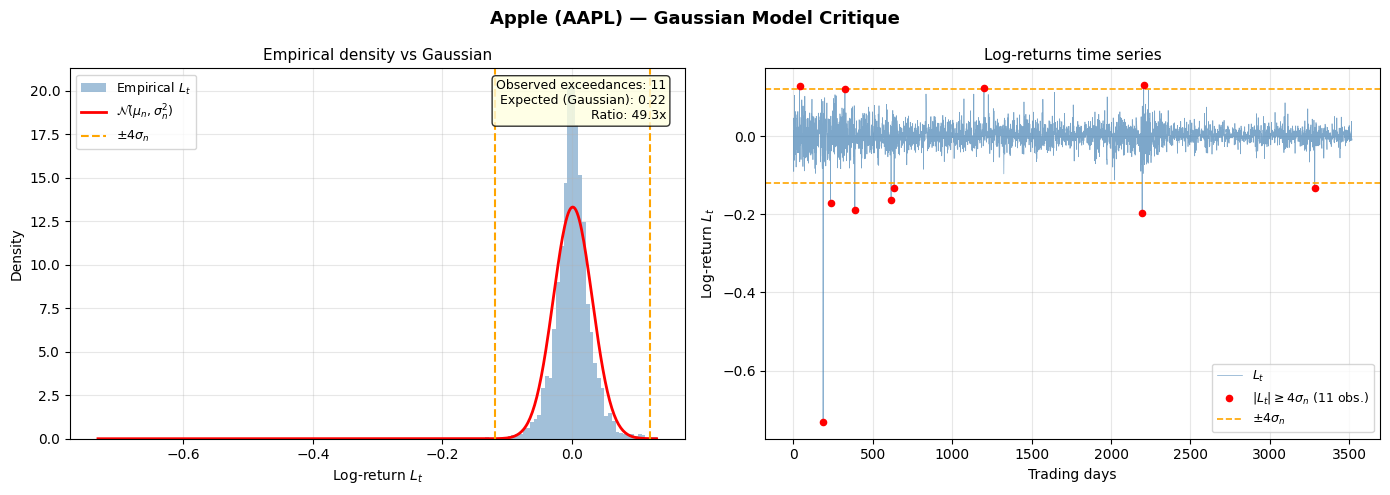

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis
import yfinance as yf


ticker = yf.Ticker("AAPL")
data   = ticker.history(start="2000-01-01", end="2013-12-31")


close       = data["Close"].dropna()
log_returns = np.log(close / close.shift(1)).dropna().values

n       = len(log_returns)
mu_n    = log_returns.mean()
sigma_n = log_returns.std(ddof=1)
s_n     = skew(log_returns)
k_n     = kurtosis(log_returns, fisher=False)

print("=" * 55)
print("  Apple (AAPL) — Jan 2000 to Dec 2013")
print("=" * 55)
print(f"  n observations     : {n}")
print(f"  Mean      mu_n     : {mu_n:.2e}")
print(f"  Std       sigma_n  : {sigma_n:.4f}")
print(f"  Skewness  s_n      : {s_n:.3f}    (Gaussian: 0)")
print(f"  Kurtosis  k_n      : {k_n:.3f}   (Gaussian: 3)")
print("=" * 55)


threshold   = 4 * sigma_n
exceedances = np.sum(np.abs(log_returns) >= threshold)
p_gaussian  = 2 * norm.cdf(-4)
expected    = n * p_gaussian

print(f"\n  Threshold 4*sigma          : {threshold:.4f}")
print(f"  Observed |L_t| >= 4sigma   : {exceedances}")
print(f"  Expected under Gaussian    : {expected:.2f}")
print(f"  Ratio observed/expected    : {exceedances/expected:.1f}x")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Apple (AAPL) — Gaussian Model Critique",
             fontsize=13, fontweight='bold')


x = np.linspace(log_returns.min(), log_returns.max(), 500)
axes[0].hist(log_returns, bins=150, density=True,
             alpha=0.5, color='steelblue', label='Empirical $L_t$')
axes[0].plot(x, norm.pdf(x, mu_n, sigma_n), 'r-', lw=2,
             label=rf'$\mathcal{{N}}(\mu_n, \sigma_n^2)$')
axes[0].axvline( threshold, color='orange', lw=1.5,
                linestyle='--', label=r'$\pm 4\sigma_n$')
axes[0].axvline(-threshold, color='orange', lw=1.5, linestyle='--')
axes[0].set_title("Empirical density vs Gaussian", fontsize=11)
axes[0].set_xlabel("Log-return $L_t$")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].annotate(
    f'Observed exceedances: {exceedances}\n'
    f'Expected (Gaussian): {expected:.2f}\n'
    f'Ratio: {exceedances/expected:.1f}x',
    xy=(0.97, 0.97), xycoords='axes fraction',
    va='top', ha='right', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))


axes[1].plot(log_returns, lw=0.5, color='steelblue', alpha=0.7,
             label='$L_t$')
exceed_idx = np.where(np.abs(log_returns) >= threshold)[0]
axes[1].scatter(exceed_idx, log_returns[exceed_idx],
                color='red', zorder=5, s=20,
                label=f'$|L_t| \geq 4\sigma_n$ ({exceedances} obs.)')
axes[1].axhline( threshold, color='orange', lw=1.2,
                linestyle='--', label=r'$\pm 4\sigma_n$')
axes[1].axhline(-threshold, color='orange', lw=1.2, linestyle='--')
axes[1].set_title("Log-returns time series", fontsize=11)
axes[1].set_xlabel("Trading days")
axes[1].set_ylabel("Log-return $L_t$")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("apple_critique.png", dpi=150)
plt.show()
